In [296]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder,OneHotEncoder

In [297]:
df = pd.read_csv('../0.dataset/dataset_karyawan_10000.csv')
df.head(5)

,ID_Karyawan,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja
0,EMP-0001,Laki-laki,IT,Cerai,SMA/SMK,Lead/Manager,Cukup
1,EMP-0002,Perempuan,IT,Menikah,SMA/SMK,Mid-Level,Sangat Baik
2,EMP-0003,Perempuan,IT,Cerai,SMA/SMK,Junior,Cukup
3,EMP-0004,Perempuan,Marketing,Belum Menikah,SMA/SMK,Senior,Baik
4,EMP-0005,Laki-laki,Finance,Belum Menikah,S2,Lead/Manager,Kurang


In [298]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_Karyawan          10000 non-null  object
 1   Jenis_Kelamin        10000 non-null  object
 2   Departemen           10000 non-null  object
 3   Status_Pernikahan    10000 non-null  object
 4   Pendidikan_Terakhir  10000 non-null  object
 5   Level_Jabatan        10000 non-null  object
 6   Rating_Kinerja       10000 non-null  object
dtypes: object(7)
memory usage: 547.0+ KB


In [299]:
df.shape

(10000, 7)

In [300]:
df.isnull().sum()

ID_Karyawan            0
Jenis_Kelamin          0
Departemen             0
Status_Pernikahan      0
Pendidikan_Terakhir    0
Level_Jabatan          0
Rating_Kinerja         0
dtype: int64

In [301]:
df.duplicated().sum()

np.int64(0)

In [302]:
df=df.drop(columns='ID_Karyawan')
df.shape

(10000, 6)

In [303]:
target_column = 'Rating_Kinerja'
feature_categori = df.drop(columns='Rating_Kinerja')


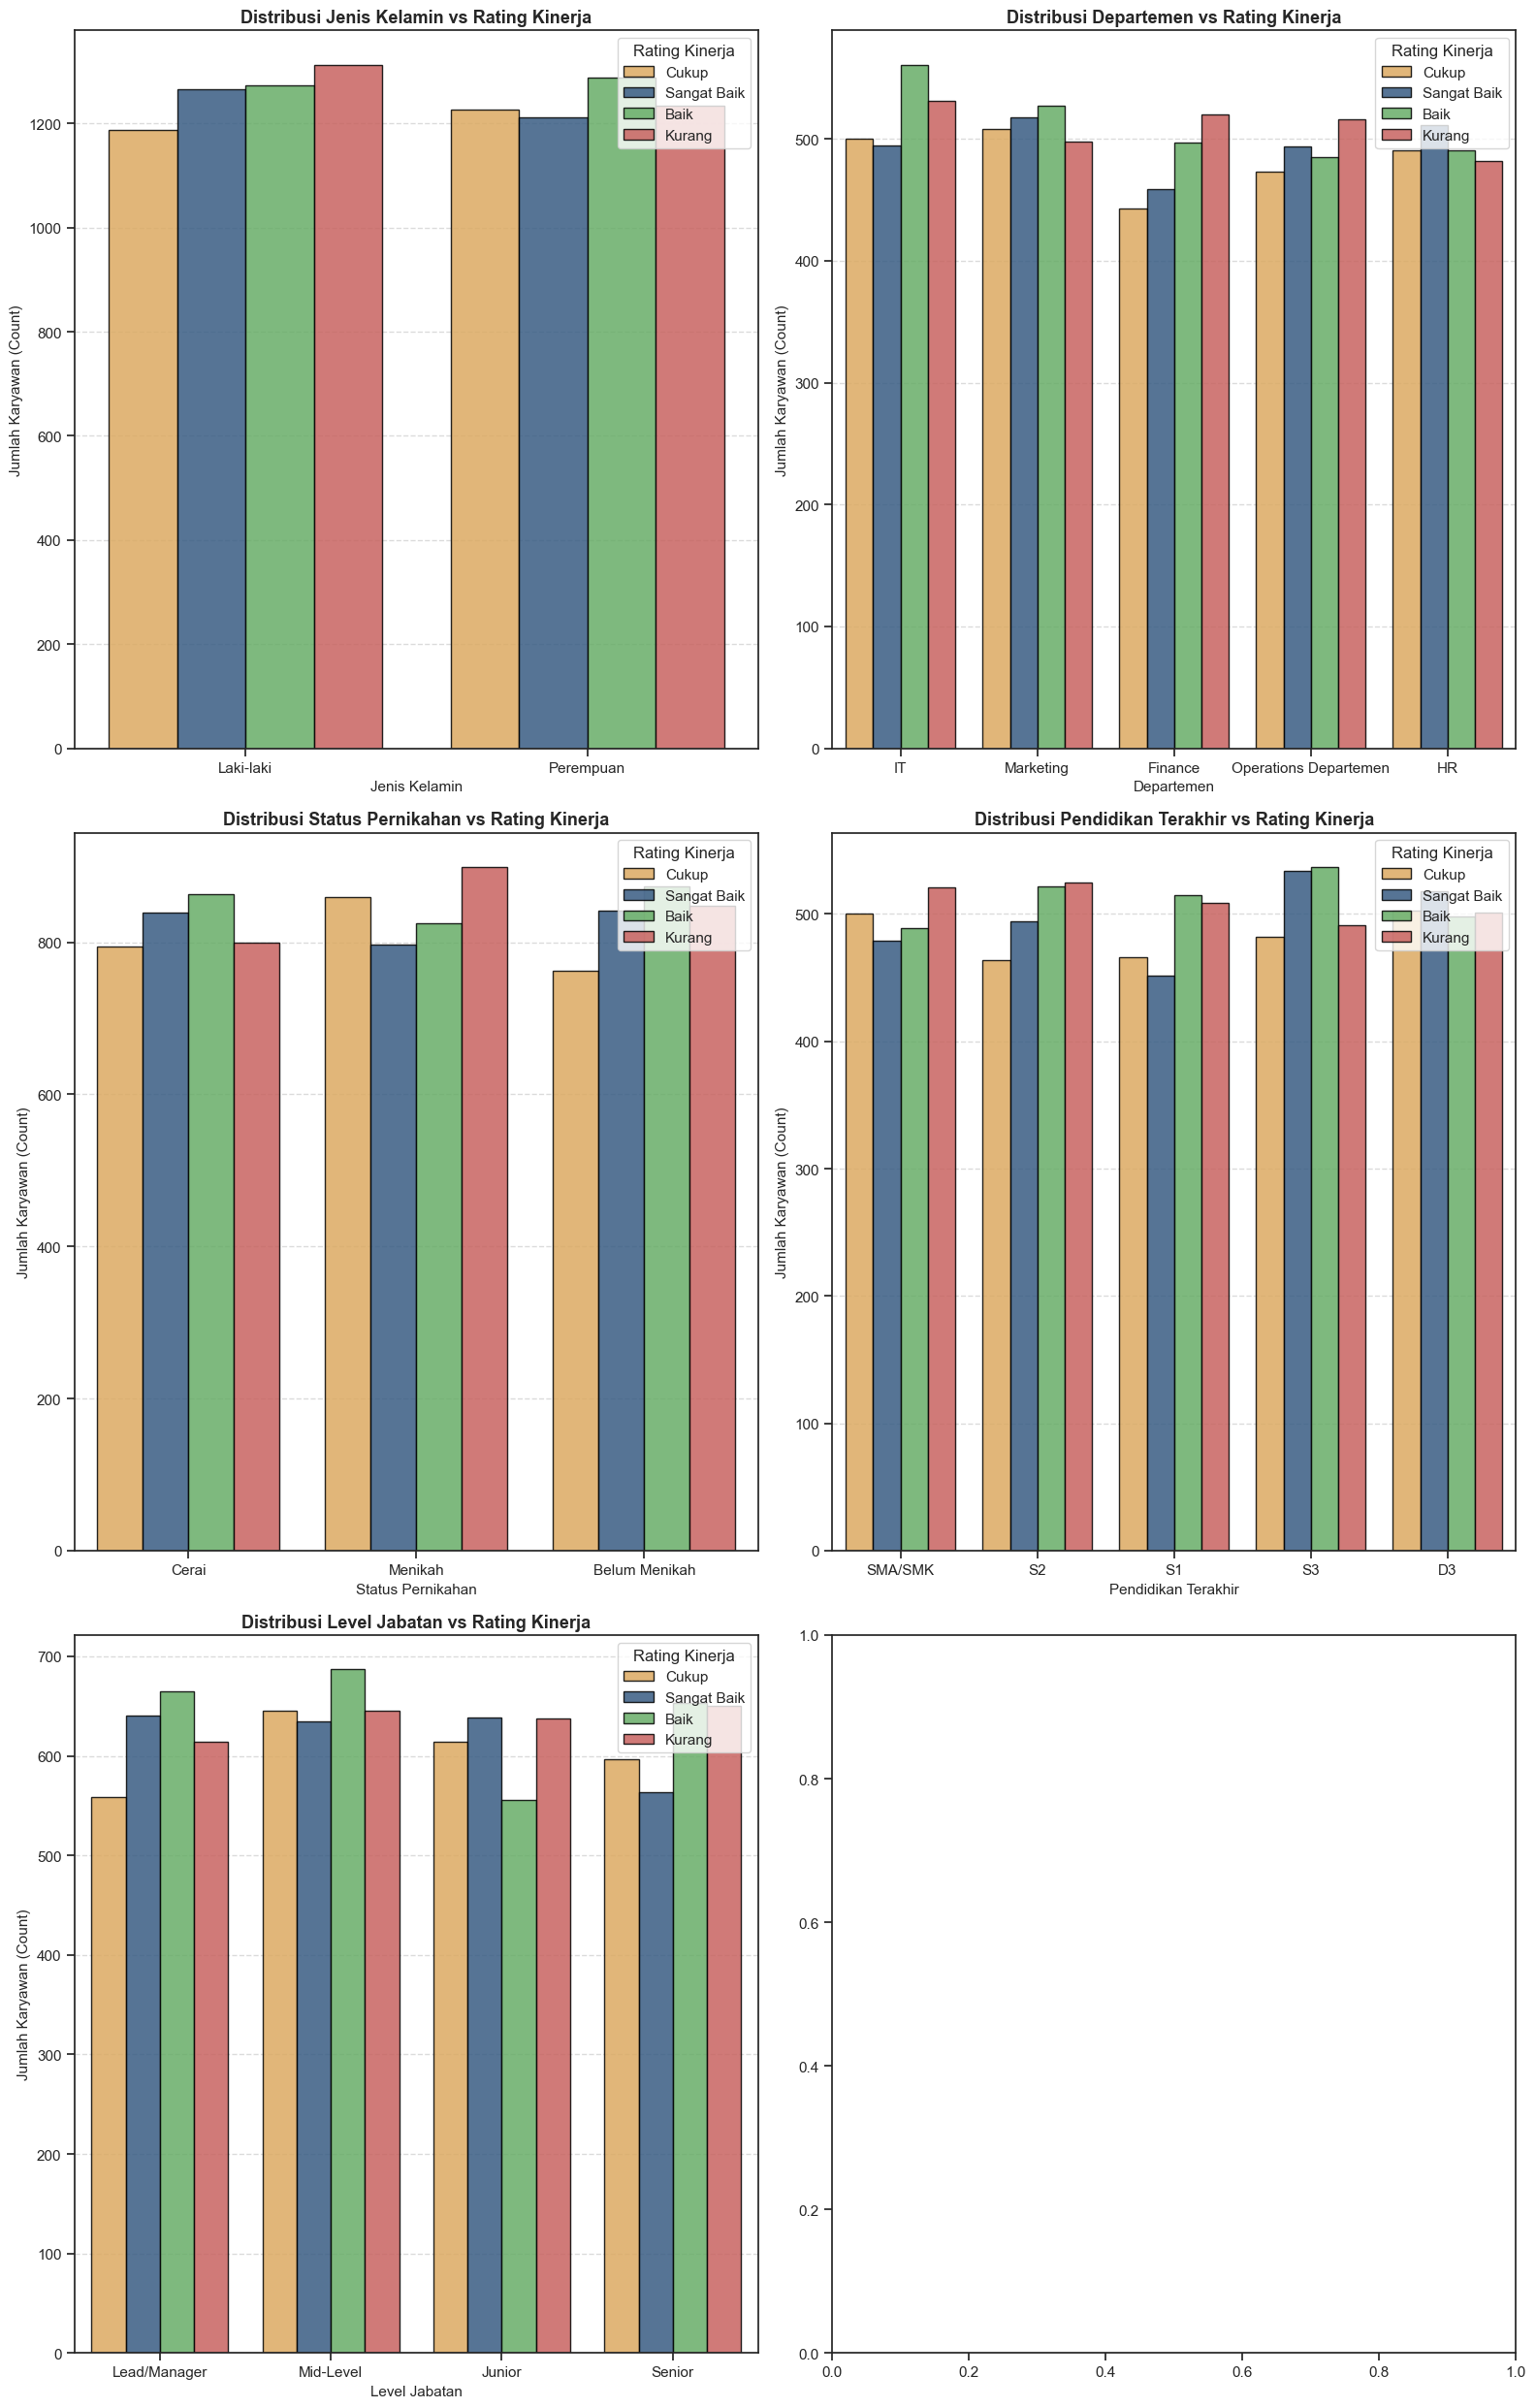

In [304]:
sns.set_theme(style="ticks")
fig, axes = plt.subplots(3, 2, figsize=(16, 25))
axes = axes.flatten()
colors = {
    "Sangat Baik": "#2b5c8f",  # Biru
    "Baik": "#5cb85c",         # Hijau
    "Cukup": "#f0ad4e",        # Kuning/Oranye
    "Kurang": "#d9534f"        # Merah
}
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=target_column,ax=axes[i],palette=colors,edgecolor="black",alpha=0.85)
    # Kustomisasi setiap grafik
    axes[i].set_title(f"Distribusi {feature.replace('_', ' ')} vs {target_column.replace('_', ' ')}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(feature.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel("Jumlah Karyawan (Count)", fontsize=11)
    axes[i].legend(title="Rating Kinerja", loc='upper right')
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# 5. Menyembunyikan subplot ke-6 (indeks 5) karena kita hanya punya 5 fitur
if len(feature_categori) < len(axes):
    axes[-1].set_visible(False)

# Mengatur tata letak agar rapi dan menampilkan grafik
plt.tight_layout()
plt.show()

## Feauture Engineering

In [305]:
def menetukan_ekonomi(row):
    pendidikan = row['Pendidikan_Terakhir']
    jabatan = row['Level_Jabatan']
    kinerja = row['Rating_Kinerja']

    if jabatan == 'Senior' or (jabatan == 'Mid-Level' and pendidikan == 'S2'):
        return 'Keatas'
    elif (jabatan == 'Junior' and pendidikan == 'D3') or kinerja == 'Kurang':
        return 'Kebawah'
    else:
        return 'Menengah'
    
df['Status_Ekonomi'] = df.apply(menetukan_ekonomi,axis=1)
df.head()

,Jenis_Kelamin,Departemen,Status_Pernikahan,Pendidikan_Terakhir,Level_Jabatan,Rating_Kinerja,Status_Ekonomi
0,Laki-laki,IT,Cerai,SMA/SMK,Lead/Manager,Cukup,Menengah
1,Perempuan,IT,Menikah,SMA/SMK,Mid-Level,Sangat Baik,Menengah
2,Perempuan,IT,Cerai,SMA/SMK,Junior,Cukup,Menengah
3,Perempuan,Marketing,Belum Menikah,SMA/SMK,Senior,Baik,Keatas
4,Laki-laki,Finance,Belum Menikah,S2,Lead/Manager,Kurang,Kebawah


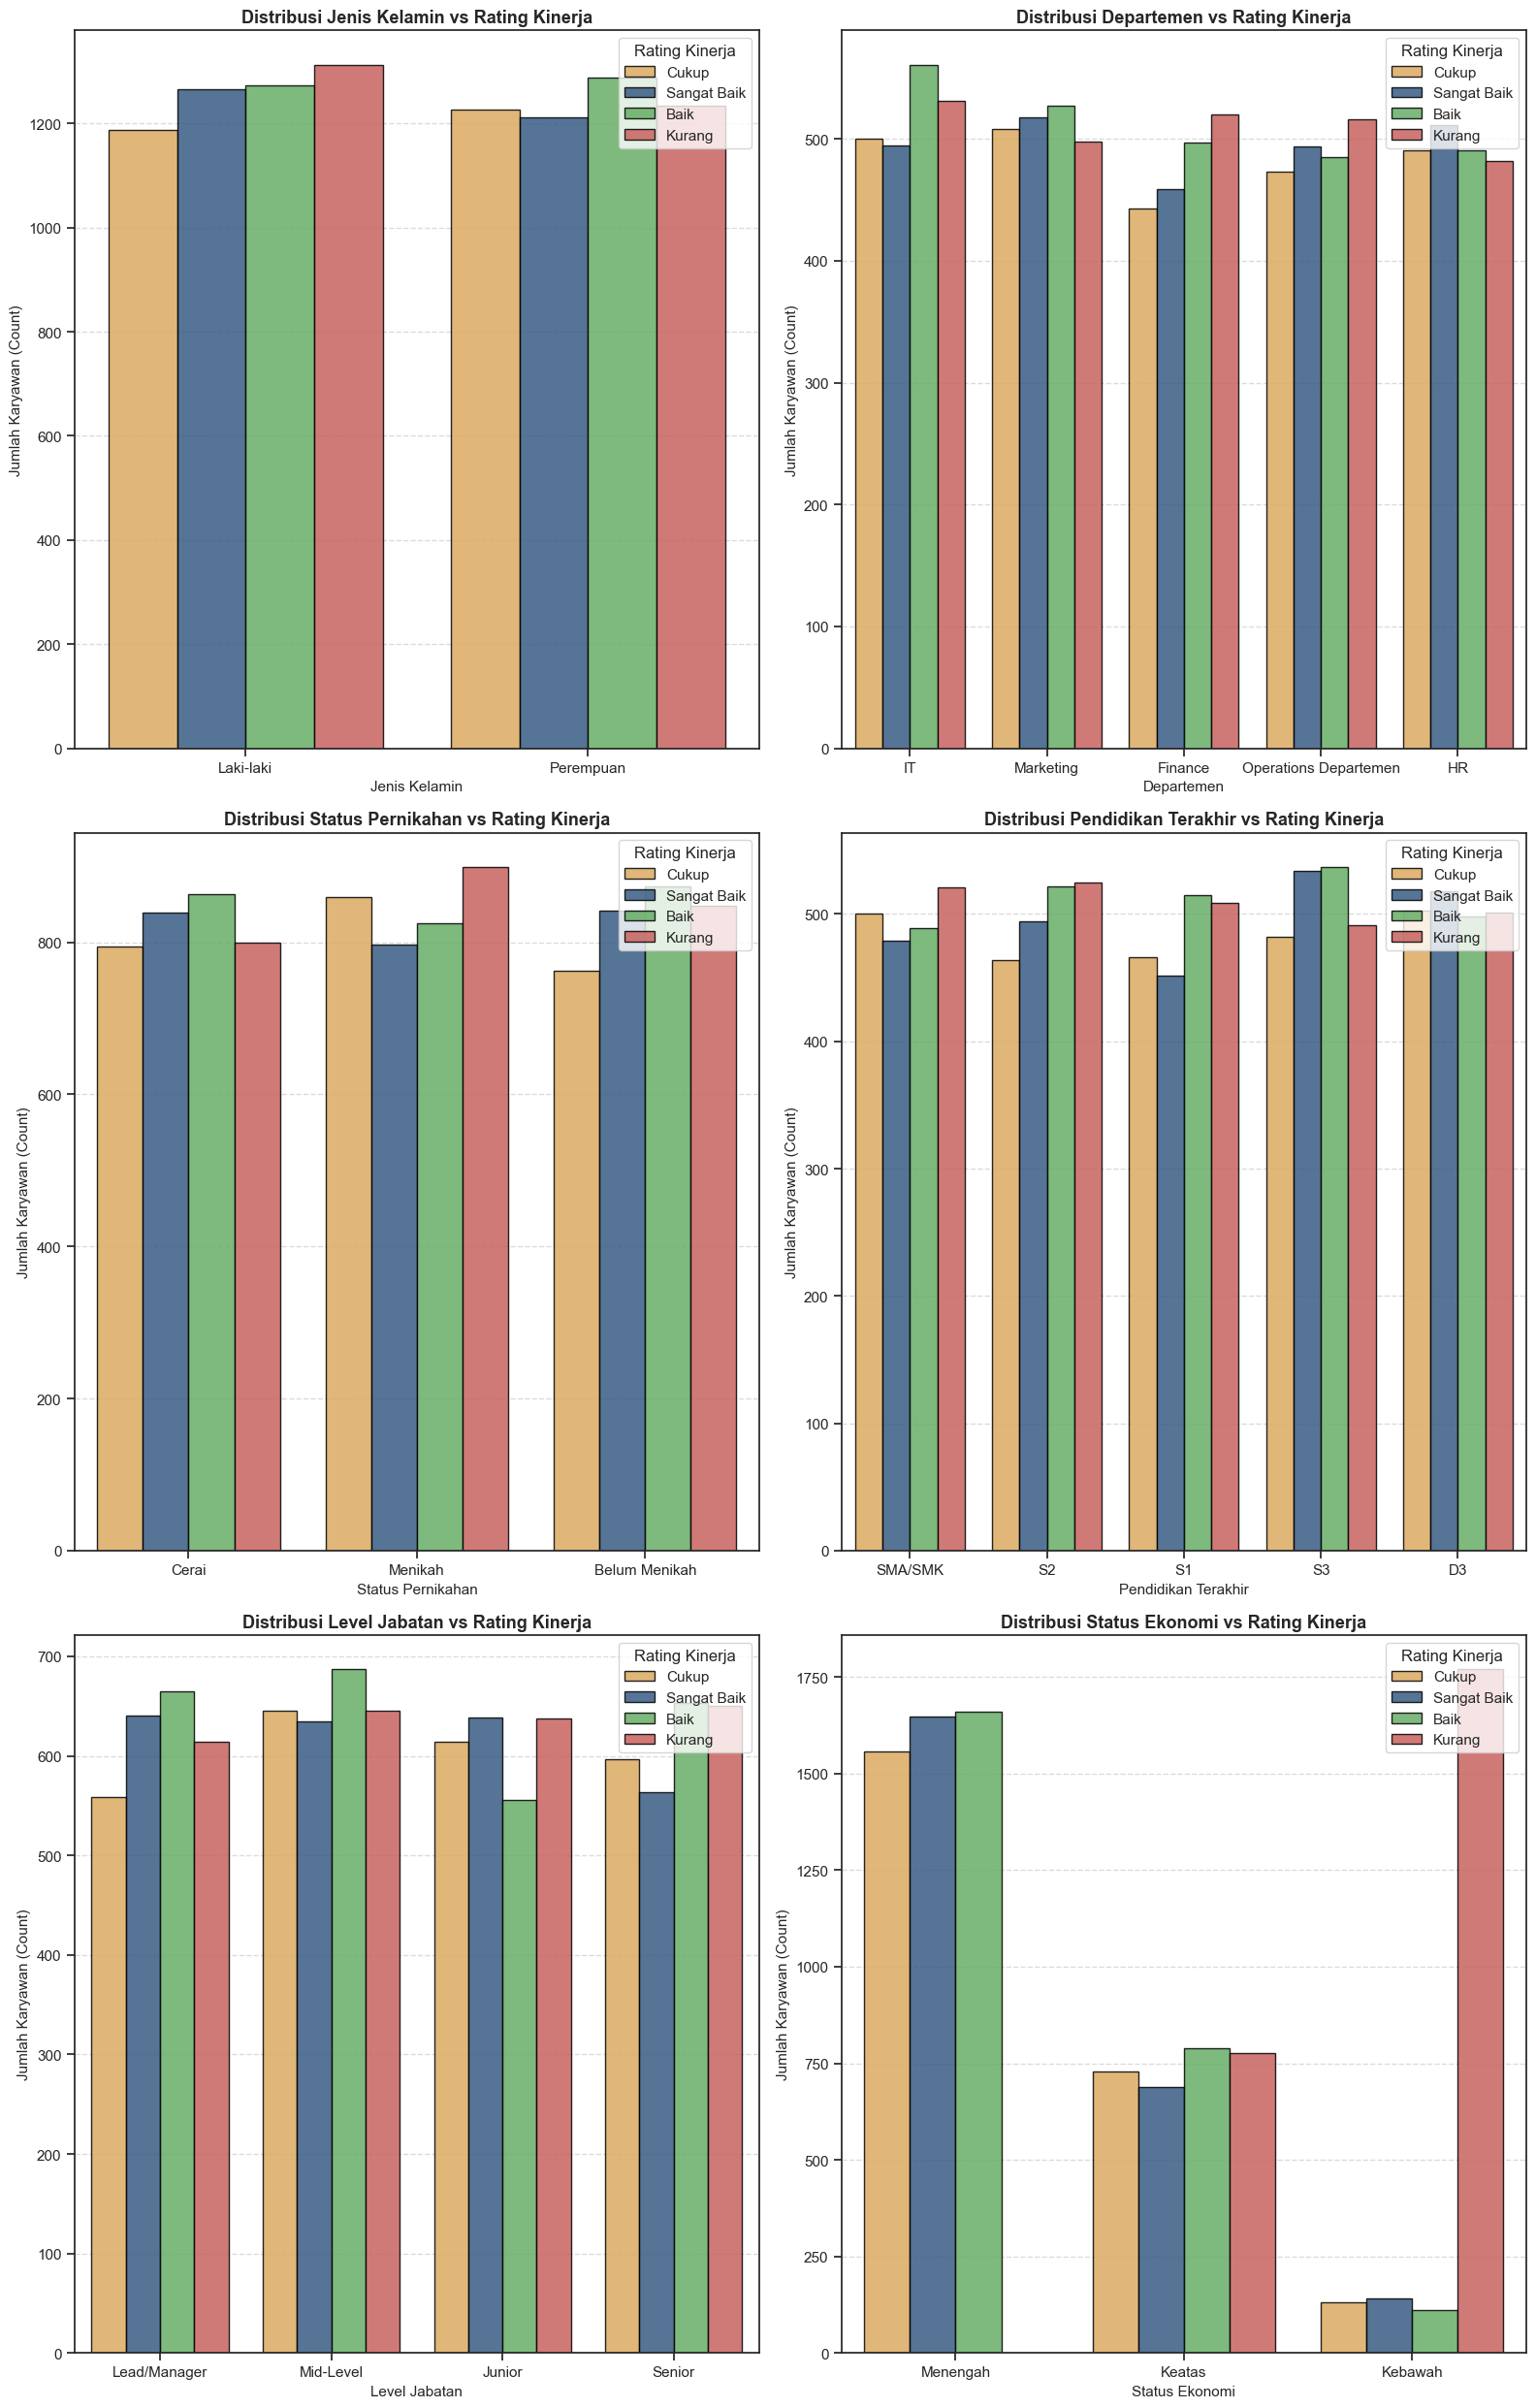

In [306]:
feature_categori = df.drop(columns='Rating_Kinerja')
sns.set_theme(style="ticks")
fig, axes = plt.subplots(3, 2, figsize=(16, 25))
axes = axes.flatten()
colors = {
    "Sangat Baik": "#2b5c8f",  # Biru
    "Baik": "#5cb85c",         # Hijau
    "Cukup": "#f0ad4e",        # Kuning/Oranye
    "Kurang": "#d9534f"        # Merah
}
for i, feature in enumerate(feature_categori):
    sns.countplot(data=df,x=feature,hue=target_column,ax=axes[i],palette=colors,edgecolor="black",alpha=0.85)
    # Kustomisasi setiap grafik
    axes[i].set_title(f"Distribusi {feature.replace('_', ' ')} vs {target_column.replace('_', ' ')}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(feature.replace('_', ' '), fontsize=11)
    axes[i].set_ylabel("Jumlah Karyawan (Count)", fontsize=11)
    axes[i].legend(title="Rating Kinerja", loc='upper right')
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

# 5. Menyembunyikan subplot ke-6 (indeks 5) karena kita hanya punya 5 fitur
if len(feature_categori) < len(axes):
    axes[-1].set_visible(False)

# Mengatur tata letak agar rapi dan menampilkan grafik
plt.tight_layout()
plt.show()

In [307]:
# colom_ordinal = ['Pendidikan_Terakhir','Level_Jabatan','Rating_Kinerja','Status_Ekonomi']
# colom_nominal = ['Jenis_Kelamin','Departemen','Status_Pernikahan']

# urutan_pendidikan = ['SMA/SMK','D3','S1','S2','S3']
# urutan_jabatan = ['Mid-Level','Junior','Senior','Lead/Manager']
# urutan_kinerja = ['Kurang','Cukup','Baik','Sangat Baik']
# urutan_ekonomi = ['Kebawah','Menengah','Keatas']

# ordinal = OrdinalEncoder(categories=[urutan_pendidikan,urutan_jabatan,urutan_kinerja,urutan_ekonomi],dtype=int)
# df[colom_ordinal] = ordinal.fit_transform(df[colom_ordinal])

# label = LabelEncoder()
# for col in df[colom_nominal].columns:
#     df[col] = label.fit_transform(df[col])
# df.head()

In [308]:
df_feature = df.drop(columns='Rating_Kinerja')
df_target = df[['Rating_Kinerja']]

urutan_kinerja = ['Kurang','Cukup','Baik','Sangat Baik']
ordinal = OrdinalEncoder(categories=[urutan_kinerja],dtype=int)
ordinal.set_output(transform="pandas")
df_target = ordinal.fit_transform(df_target[['Rating_Kinerja']])

encoder = OneHotEncoder(sparse_output=False,drop=None,dtype=int)
encoded_features = encoder.fit_transform(df_feature)
df_feature = pd.DataFrame(encoded_features,columns=encoder.get_feature_names_out(df_feature.columns))

df_final = pd.concat([df_feature, df_target], axis=1)

In [309]:
df_final.to_csv("dataset_Kinerja_Karyawan_clean.csv", index=False)
df_final.head()

,Jenis_Kelamin_Laki-laki,Jenis_Kelamin_Perempuan,Departemen_Finance,Departemen_HR,Departemen_IT,Departemen_Marketing,Departemen_Operations Departemen,Status_Pernikahan_Belum Menikah,Status_Pernikahan_Cerai,Status_Pernikahan_Menikah,...,Pendidikan_Terakhir_S3,Pendidikan_Terakhir_SMA/SMK,Level_Jabatan_Junior,Level_Jabatan_Lead/Manager,Level_Jabatan_Mid-Level,Level_Jabatan_Senior,Status_Ekonomi_Keatas,Status_Ekonomi_Kebawah,Status_Ekonomi_Menengah,Rating_Kinerja
0,1,0,0,0,1,0,0,0,1,0,...,0,1,0,1,0,0,0,0,1,1
1,0,1,0,0,1,0,0,0,0,1,...,0,1,0,0,1,0,0,0,1,3
2,0,1,0,0,1,0,0,0,1,0,...,0,1,1,0,0,0,0,0,1,1
3,0,1,0,0,0,1,0,1,0,0,...,0,1,0,0,0,1,1,0,0,2
4,1,0,1,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,1,0,0
